# CPTAC PDAC Proteome Preprocessing

This notebook preprocesses CPTAC PDAC proteome data into tumor and normal matrices for downstream multi-omics harmonization.

## Inputs

- Proteome matrices: `proteomics_PDAC.txt`, `proteomics_Normal.txt`
- Metadata: `clinical_CPTAC.tsv`
- Mutations for KRAS VAF filtering: `Mutation_results.maf.txt`
- Gene mapping: `data/processed/genelist/`

## Outputs

- `proteome_cancer_pre_harmonized_with_header.txt`
- `proteome_healthy_pre_harmonized_with_header.txt`

## Pipeline

1. Load tumor and normal proteome matrices.
2. Remove low-purity tumor samples using the lowest observed KRAS VAF from the CPTAC mutation MAF, with a manual exclusion for C3N-01012 based on low neoplastic cellularity reported for the dataset.
3. Quantify and diagnose missingness before filtering.
4. Remove proteins with high missingness and impute remaining values using QRILC only.
5. Prepare and save pre-harmonized proteome matrices for the downstream multi-omics harmonization step.

In [ ]:
from pathlib import Path

import pandas as pd

from utils.proteome_processing import (
    finalize_proteome_matrices,
    filter_samples_by_kras_vaf,
    impute_missing_values_qrilc,
    load_proteome_data,
    prepare_cptac_cell_composition_metadata,
    remove_genes_with_high_na,
    run_missingness_mechanism_diagnostics,
    save_proteome_outputs,
    summarize_filtered_missingness,
    summarize_metadata_coverage,
    summarize_missingness_overview,
)

## Setup

Notebook helper functions are imported from `Pipeline/Data Preprocessing/utils/proteome_processing.py`. Imports and configuration are kept together so the notebook can be rerun top-to-bottom with explicit paths and thresholds.

In [ ]:
proteome_file = "../../data/raw/proteome/proteomics_PDAC.txt"
proteome_norm_file = "../../data/raw/proteome/proteomics_Normal.txt"
clinical_file = "../../data/clinical/clinical_CPTAC.tsv"
mutation_maf_file = "../../data/clinical/Mutation_results.maf.txt"
mapping_dir = "../../data/processed/genelist/"
output_dataset_dir = "../../data/processed/proteome/"
out_proteome_norm_header = output_dataset_dir + "proteome_healthy_pre_harmonized_with_header.txt"
out_proteome_tumor_header = output_dataset_dir + "proteome_cancer_pre_harmonized_with_header.txt"
cell_composition_columns = [
    "Neoplastic_cellularity",
    "Acinar_fraction",
    "Islet_fraction",
    "Stromal_fraction",
    "Non_neoplastic_duct",
    "Fat_fraction",
    "Inflammation_fraction",
    "Muscle_fraction",
]
QRILC_TUNE_SIGMA = 1.0
KRAS_VAF_THRESHOLD = 0.075
MANUAL_KRAS_VAF_EXCLUSIONS = ["C3N-01012"]

## Step 1: Load Data And Filter Samples

In [ ]:
proteome_tumor_load = load_proteome_data(proteome_file)
proteome_norm_load = load_proteome_data(proteome_norm_file)
clinical_cptac = pd.read_csv(clinical_file, sep="\t", low_memory=False)

print("Filtering tumor proteome samples by KRAS VAF...")
proteome_tumor_load, clinical_cptac = filter_samples_by_kras_vaf(
    proteome_tumor_load,
    clinical_cptac,
    mutation_maf_file,
    vaf_threshold=KRAS_VAF_THRESHOLD,
    extra_removed_samples=MANUAL_KRAS_VAF_EXCLUSIONS,
)

## Step 2: Summarize Missingness

,Genes with NAs,Avg NA fraction (per gene),Total NAs,Overall NA fraction
Dataset,,,,
Normal (healthy),5913 / 11662,0.2483,"217,164 / 874,650",0.2483
Tumor (cancer),5895 / 11662,0.2463,"402,161 / 1,632,680",0.2463


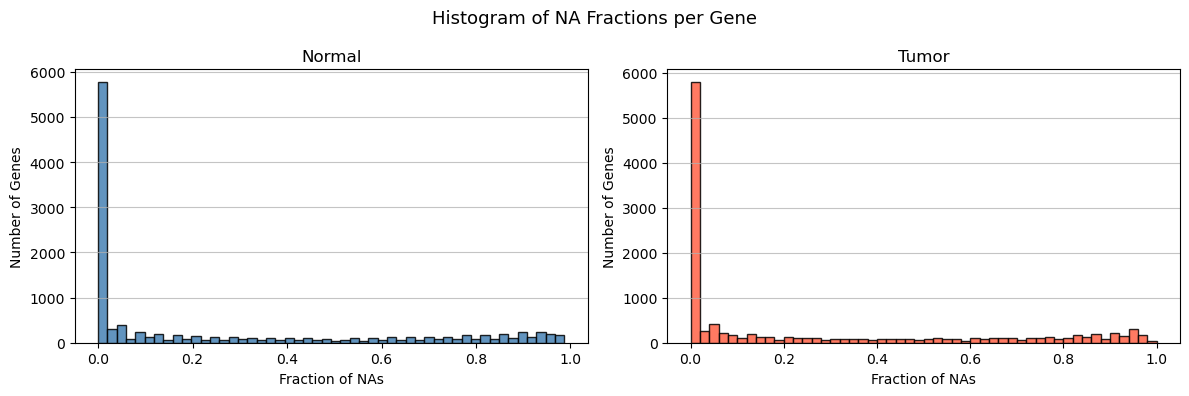

In [ ]:
na_norm_fraction, na_tumor_fraction, na_summary = summarize_missingness_overview(
    proteome_norm_load,
    proteome_tumor_load,
)
display(na_summary)

## Step 3: Diagnose Missingness Patterns

MAR and MNAR cannot be proven from observed data alone, but these diagnostics help justify a left-censored imputation strategy for the retained tumor cohort.

- MAR-compatible pattern: missingness tracks observed sample properties.
- MNAR-compatible pattern: lower-intensity proteins show more missingness.
This is supporting evidence for QRILC, not a proof of mechanism.

In [ ]:
tumor_sample_metadata = prepare_cptac_cell_composition_metadata(
    clinical_file=clinical_file,
    sample_ids=proteome_tumor_load.columns,
    metadata_columns=cell_composition_columns,
)

print("Matched cell composition coverage:")
print(summarize_metadata_coverage(tumor_sample_metadata).to_string())

missingness_diagnostics = []
missingness_details = {}

for dataset_name, dataset_df, sample_metadata, metadata_columns in [
    ("Normal proteome", proteome_norm_load, None, None),
    ("Tumor proteome", proteome_tumor_load, tumor_sample_metadata, cell_composition_columns),
]:
    summary, details = run_missingness_mechanism_diagnostics(
        dataset_df,
        dataset_name,
        sample_metadata=sample_metadata,
        metadata_columns=metadata_columns,
    )
    missingness_diagnostics.append(summary)
    missingness_details[dataset_name] = details

missingness_diagnostics_df = pd.concat(missingness_diagnostics, ignore_index=True)
print("\nCombined missingness summary")
print(missingness_diagnostics_df.round(3).to_string(index=False))

display(
    missingness_diagnostics_df.loc[
        missingness_diagnostics_df["dataset"] == "Tumor proteome",
        ["dataset", "strongest_metadata_feature", "strongest_metadata_spearman"],
    ]
)

## Step 4: Filter High-Missing Proteins And Impute With QRILC

Only QRILC is retained in this workflow. The notebook therefore filters proteins with excessive missingness and imputes the remaining values directly with the QRILC-based helper used downstream.

In [ ]:
proteome_norm_clean = remove_genes_with_high_na(proteome_norm_load, na_norm_fraction, threshold=0.5)
proteome_tumor_clean = remove_genes_with_high_na(proteome_tumor_load, na_tumor_fraction, threshold=0.5)

post_filter_summary = summarize_filtered_missingness(
    proteome_norm_clean,
    proteome_tumor_clean,
)
print("After filtering:")
display(post_filter_summary)

In [ ]:
print("Running QRILC (per-gene quantile regression) - this may take a moment...")
proteome_norm_imputed = impute_missing_values_qrilc(
    proteome_norm_clean,
    tune_sigma=QRILC_TUNE_SIGMA,
    random_state=42,
)
proteome_tumor_imputed = impute_missing_values_qrilc(
    proteome_tumor_clean,
    tune_sigma=QRILC_TUNE_SIGMA,
    random_state=42,
)
print("QRILC done.")

## Step 5: Save Outputs

In [ ]:
proteome_norm_df = proteome_norm_imputed.copy()
proteome_tumor_df = proteome_tumor_imputed.copy()

proteome_norm_df, proteome_tumor_df, final_genes = finalize_proteome_matrices(
    proteome_norm_df,
    proteome_tumor_df,
    mapping_dir=mapping_dir,
)

In [ ]:
proteome_norm_df, proteome_tumor_df = save_proteome_outputs(
    proteome_norm_df,
    proteome_tumor_df,
    out_proteome_norm_header=out_proteome_norm_header,
    out_proteome_tumor_header=out_proteome_tumor_header,
)